# Практическая работа №5: Элементы регрессионного анализа. Выборочные прямые среднеквадратической регрессии. Корреляционные отношения

Выполнили студенты гр. 2384 Лукьянова Мария и Пчелинцева Кристина.

## Цель работы

Ознакомление с основными положениями метода наименьших квадратов (МНК), со статистическими свойствами МНК оценок, с понятием функции регрессии и роли МНК-в регрессионном анализе, с корреляционным отношением, как мерой тесноты произвольной (в том числе и линейной) корреляционной связи.

## Основные теоретические положения

Уравнения выборочных прямых среднеквадратической регрессии :

${\overline{y}}_x=\overline{y}+\overline{r}\frac{S_y}{S_x}\left(x-\overline{x}\right)$,

${\overline{x}}_y=\overline{x}+\overline{r}\frac{S_x}{S_y}(y-\overline{y})$

Оценка остаточной дисперсии:

$\sigma_x^2\left(1-r^2\right)$

Выборочное корелляционное отношение:

$\eta_{xy}=\frac{{\overline{\sigma}}_{{\overline{x}}_y}}{{\overline{\sigma}}_x}$




## Постановка задачи

Для заданной двумерной выборки
(
X
,
Y
)
 построить уравнения выборочных прямых среднеквадратической регрессии. Полученные линейные функции регрессии отобразить графически. Найти выборочное корреляционное отношение. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы

## Пункт 1.
Отобразить двумерную выборку на графике.


In [22]:
import numpy as np
import pandas as pd

In [23]:
from google.colab import files

uploaded = files.upload()

import pandas as pd
df = pd.read_csv("team33_pr1.csv")
df

Saving team33_pr1.csv to team33_pr1 (1).csv


,PS,PPY
0,123.274162,2694.000000
1,93.688363,3448.333333
2,114.398422,2213.571429
3,147.928994,3375.000000
4,123.274162,2830.833333
...,...,...
106,148.000000,3419.750000
107,93.688363,3525.000000
108,114.398422,2500.000000
109,123.274162,2358.000000


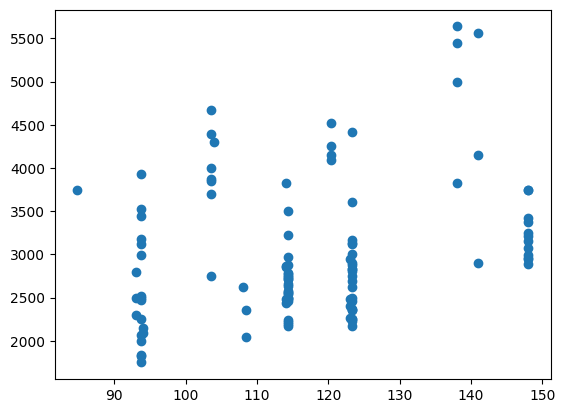

In [24]:
import matplotlib.pyplot as plt
plt.scatter(df.PS, df.PPY)
plt.show()

### Пункт 2
Для заданной выборки построить уравнения средней квадратичной регрессии
x
 на
y
 и
y
 на
x
 соответственно. Построить полученные прямые на множестве выборки. Объяснить результаты.

Уравнение регрессии Y на X: Y = 1317.62 + 14.42 * X
Уравнение регрессии X на Y: X = 98.76 + 0.01 * Y


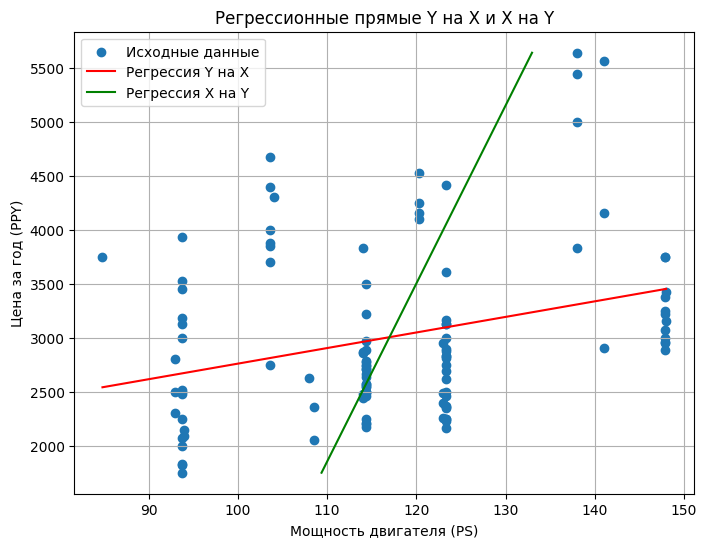

In [25]:
X = np.array(df['PS'])  # Мощность двигателя (PS)
Y = np.array(df['PPY'])  # Цена за год (PPY)

# Вычисление среднего и стандартного отклонения
mean_x = np.mean(X)
mean_y = np.mean(Y)
S_x = np.std(X, ddof=1)
S_y = np.std(Y, ddof=1)

# Коэффициент корреляции
r = np.corrcoef(X, Y)[0, 1]

# Регрессия Y на X
b = r * S_y / S_x
a = mean_y - b * mean_x
x_values = np.linspace(min(X), max(X), 100)  # Линейные значения для оси X
y_reg = a + b * x_values

# Регрессия X на Y
d = r * S_x / S_y
c = mean_x - d * mean_y
y_values = np.linspace(min(Y), max(Y), 100)  # Линейные значения для оси Y
x_reg = c + d * y_values

# Печать уравнений регрессии
print(f"Уравнение регрессии Y на X: Y = {a:.2f} + {b:.2f} * X")
print(f"Уравнение регрессии X на Y: X = {c:.2f} + {d:.2f} * Y")

# Построение графиков
plt.figure(figsize=(8, 6))
plt.scatter(X, Y, label='Исходные данные')
plt.plot(x_values, y_reg, color='red', label='Регрессия Y на X')
plt.plot(x_reg, y_values, color='green', label='Регрессия X на Y')
plt.title('Регрессионные прямые Y на X и X на Y')
plt.xlabel('Мощность двигателя (PS)')
plt.ylabel('Цена за год (PPY)')
plt.grid(True)
plt.legend()
plt.show()

Построенные функции минимизируют среднеквадратическую ошибку, но так как данные имеют некоторую степень шума и могут содержать нелинейные зависимости, построенные линейные функции не могут точно описать все наблюдения. На графике видно, что линии регрессии пересекаются в точке, где значения обеих переменных равны их средним значениям. Это связано с тем, что метод наименьших квадратов гарантирует, что линия будет проходить через среднее значение по каждой из переменных.

### Пункт 3.
Составить корреляционную таблицу для нахождения выборочного корреляционного отношения. Убедиться, что неравенства $\eta_{xy} \geqslant |r_{xy}|$ и $\eta_{yx} \geqslant |r_{xy}|$ выполняются.

In [26]:
data = np.array(df)

k = round(1 + int(np.log2(len(df))))
bins1 = pd.cut(df["PS"], bins=k, right=False, precision=6)
bins2 = pd.cut(df["PPY"], bins=k, right=False, precision=6)

contingency_table = pd.crosstab(bins2, bins1,  margins=True, margins_name="Total")

table = np.array(contingency_table)
intervals1 = bins1.cat.categories
intervals2 = bins2.cat.categories
weights_x = np.array([(interval.left + interval.right) / 2 for interval in intervals1])
weights_y = np.array([(interval.left + interval.right) / 2 for interval in intervals2])

n_y = table[:-1, -1]
print(n_y)
weighted_means_rows = []
for i in range(table.shape[0] - 1):
    row = np.array(table[i, :-1])
    weighted_mean = np.sum(row * weights_x) / n_y[i]
    weighted_means_rows.append(weighted_mean)

print("Условное выборочно среднее по строкам:")
for i, mean in enumerate(weighted_means_rows):
    print(f"{mean:.2f}")

n_x = table[-1, :-1]
print(n_x)
weighted_means_cols = []
for j in range(table.shape[1] - 1):
    col = table[:-1, j]
    weighted_mean = np.sum(col * weights_y) / n_x[j]
    weighted_means_cols.append(weighted_mean)

print("\nУсловное выборочно среднее по столбцам:")
for j, mean in enumerate(weighted_means_cols):
    print(f"{mean:.2f}")


contingency_table.rename(index={"Total": "$n_x$"}, columns={"Total": "$n_y$"}, inplace=True)
markdown_table = contingency_table.to_markdown()
print(markdown_table)

[19 40 24 14  9  2  3]
Условное выборочно среднее по строкам:
106.43
115.28
126.95
114.48
117.41
120.92
137.48
[19  2 11 33 27  4 15]

Условное выборочно среднее по столбцам:
2699.32
2026.90
3491.34
2851.70
2726.39
4805.26
3471.27
| PPY                        |   [84.812623, 93.839391) |   [93.839391, 102.866159) |   [102.866159, 111.892928) |   [111.892928, 120.919696) |   [120.919696, 129.946464) |   [129.946464, 138.973232) |   [138.973232, 148.063187) |   $n_y$ |
|:---------------------------|-------------------------:|--------------------------:|---------------------------:|---------------------------:|---------------------------:|---------------------------:|---------------------------:|--------:|
| [1749.166667, 2304.642857) |                        7 |                         2 |                          1 |                          4 |                          5 |                          0 |                          0 |      19 |
| [2304.642857, 2860.119048) |                

Таблица 1

| NCP                  |   [42.0, 58.948486) |   [58.948486, 75.896973) |   [75.896973, 92.845459) |   [92.845459, 109.793946) |   [109.793946, 126.742432) |   [126.742432, 143.690919) |   [143.690919, 160.758044) |   $n_y$ | $\bar x_y$ |
|:---------------------|--------------------:|-------------------------:|-------------------------:|--------------------------:|---------------------------:|---------------------------:|---------------------------:|--------:|----:|
| [1.0, 1.428571)      |                   5 |                        3 |                        4 |                         2 |                          0 |                          0 |                          0 |      14 | 71.05|
| [1.428571, 1.857143) |                   0 |                        0 |                        1 |                         0 |                          1 |                          0 |                          0 |       2 |101.32|
| [1.857143, 2.285714) |                   1 |                        0 |                        0 |                         2 |                          0 |                          0 |                          0 |       3 |84.37|
| [2.285714, 2.714286) |                   1 |                        0 |                        1 |                         4 |                          0 |                          0 |                          0 |       6 |90.02|
| [2.714286, 3.142857) |                   9 |                       14 |                       12 |                         7 |                         17 |                          1 |                          2 |      62 |89.84|
| [3.142857, 3.571429) |                   1 |                        1 |                        0 |                         0 |                          0 |                          0 |                          0 |       2 |58.95|
| [3.571429, 4.003)    |                   3 |                        2 |                        0 |                         1 |                          0 |                          0 |                          0 |       6 |64.60|
| $n_x$                |                  20 |                       20 |                       18 |                        16 |                         18 |                          1 |                          2 |      95 |
| $\bar y_x$ | 2.59 | 2.78 | 2.45 | 2.55 |2.86 |2.93 | 2.93|

In [27]:
x_bar_y = weighted_means_rows
y_bar_x = weighted_means_cols

n_total = np.sum(n_y)

mean_y = np.sum(n_y * x_bar_y) / n_total
var_y = np.sum(n_y * (x_bar_y - mean_y) ** 2) / n_total

mean_x = np.sum(n_x * y_bar_x) / n_total
var_x = np.sum(n_x * (y_bar_x - mean_x) ** 2) / n_total

y_pred = y_bar_x
var_y_pred = np.sum(n_x * (y_pred - mean_y) ** 2) / n_total

x_pred = x_bar_y
var_x_pred = np.sum(n_y * (x_pred - mean_x) ** 2) / n_total

eta_xy = np.sqrt(var_y_pred / var_y)
eta_yx = np.sqrt(var_x_pred / var_x)

cov_xy = np.sum(n_x * (y_bar_x - mean_x) * (x_bar_y - mean_y)) / n_total
r_xy = cov_xy / np.sqrt(var_x * var_y)

# 7. Проверка неравенств
print(f"η_xy: {eta_xy:.4f}")
print(f"η_yx: {eta_yx:.4f}")
print(f"r_xy: {r_xy:.4f}")

print("\nПроверка неравенств:")
print(f"η_xy >= |r_xy|: {eta_xy >= abs(r_xy)}")
print(f"η_yx >= |r_xy|: {eta_yx >= abs(r_xy)}")

η_xy: 397.2792
η_yx: 6.0244
r_xy: 0.7695

Проверка неравенств:
η_xy >= |r_xy|: True
η_yx >= |r_xy|: True


Корреляционное отношение $r_{xy}=0.77$ подтверждает умеренную положительную связь между мощностью двигателя и ценой за год, а вычисленные значения $\eta_{xy}$ и $\eta_{yx}$ подтверждают выполнение неравенств и сильную линейную зависимость.

### Пункт 4.
Для заданной выборки построить корреляционную кривую параболического вида
$y = \beta_0 + \beta_1x + \beta_2x^2$, сделать выводы.

Коэффициенты параболической регрессии:
β_0 = 0.0076
β_1 = -1.3094
β_2 = 165.6748


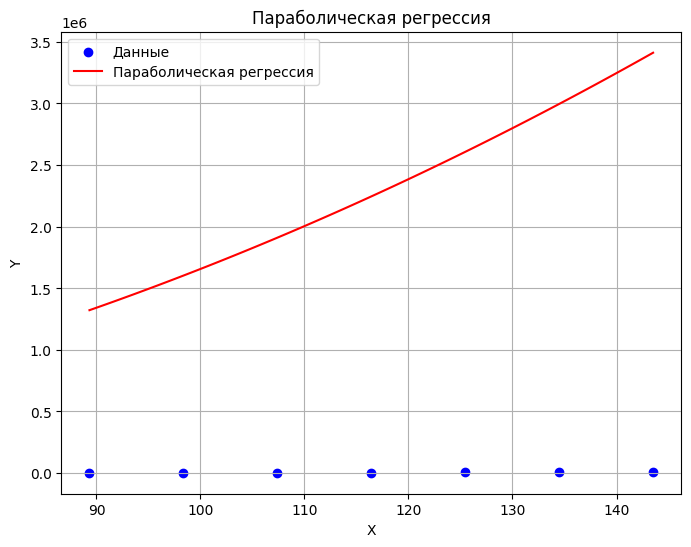

In [28]:
x_values = weights_x
y_values = weights_y

sum_x4 = np.sum(n_x * x_values ** 4)
sum_x3 = np.sum(n_x * x_values ** 3)
sum_x2 = np.sum(n_x * x_values ** 2)
sum_x = np.sum(n_x * x_values)

sum_yx2 = np.sum(n_x * weighted_means_rows * x_values ** 2)
sum_yx = np.sum(n_x * weighted_means_rows * x_values)
sum_y = np.sum(n_x * weighted_means_rows)

A = np.array([
    [sum_x4, sum_x3, sum_x2],
    [sum_x3, sum_x2, sum_x],
    [sum_x2, sum_x, np.sum(n_x)]
])
B = np.array([sum_yx2, sum_yx, sum_y])

# Решение системы
beta = np.linalg.solve(A, B)
beta_0, beta_1, beta_2 = beta

print(f"Коэффициенты параболической регрессии:")
print(f"β_0 = {beta_0:.4f}")
print(f"β_1 = {beta_1:.4f}")
print(f"β_2 = {beta_2:.4f}")

x_fit = np.linspace(min(x_values), max(x_values), 100)
y_fit = beta_0 + beta_1 * x_fit + beta_2 * x_fit ** 2

plt.figure(figsize=(8, 6))
plt.scatter(x_values, y_values, color='blue', label='Данные')
plt.plot(x_fit, y_fit, color='red', label='Параболическая регрессия')
plt.title('Параболическая регрессия')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.legend()
plt.show()



График полученной регрессии значительно отклоняется от реальных значений выборки, что свидетельствует о том, что параболическая модель не является подходящей для этих данных. Это может указывать на то, что выборочные данные скорее следуют линейной зависимости, и использование полинома второго порядка приводит к чрезмерной кривизне.

### Пункт 5
Для заданной выборки построить корреляционную кривую в зависимости от номера варианта и сделать выводы:
$ y = \beta_0\exp(\beta_1x)$ - показательная функция


Коэффициенты показательной регрессии:
β_0 = 1664.3820
β_1 = 0.0048


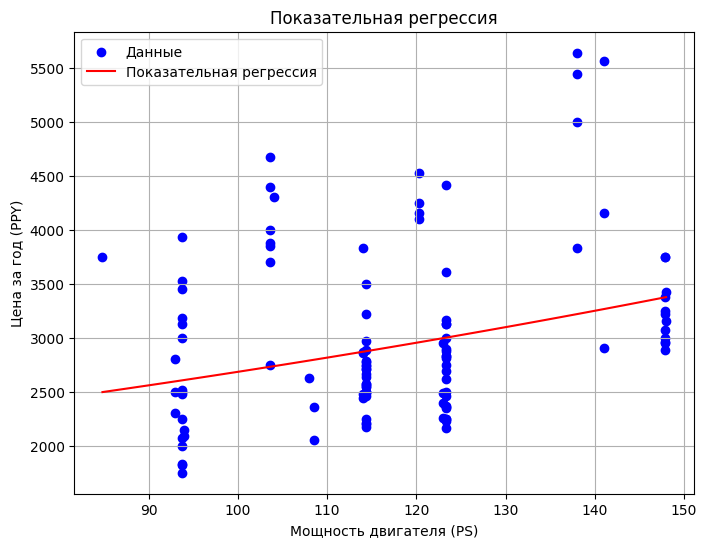

In [29]:
x_values = X
y_values = Y

z_values = np.log(y_values)  # z = ln(y)

n = len(x_values)
sum_x = np.sum(x_values)
sum_z = np.sum(z_values)
sum_xz = np.sum(x_values * z_values)
sum_x2 = np.sum(x_values ** 2)

A = np.array([
    [n, sum_x],
    [sum_x, sum_x2]
])
B = np.array([sum_z, sum_xz])

a, beta_1 = np.linalg.solve(A, B)
beta_0 = np.exp(a)

print(f"Коэффициенты показательной регрессии:")
print(f"β_0 = {beta_0:.4f}")
print(f"β_1 = {beta_1:.4f}")

x_fit = np.linspace(min(x_values), max(x_values), 100)
y_fit = beta_0 * np.exp(beta_1 * x_fit)

plt.figure(figsize=(8, 6))
plt.scatter(x_values, y_values, color='blue', label='Данные')
plt.plot(x_fit, y_fit, color='red', label='Показательная регрессия')
plt.title('Показательная регрессия')
plt.xlabel('Мощность двигателя (PS)')
plt.ylabel('Цена за год (PPY)')
plt.grid(True)
plt.legend()
plt.show()

Данная выборка не поддается адекватному описанию показательной функцией, поскольку график полученной регрессии практически совпадает с линейной зависимостью. Это может указывать на то, что данные не следуют показательной закономерности, а скорее подчиняются линейной связи между переменными.

### Пункт 6
Вычислить следующие показатели качества регрессии для каждой кривой и сделать выводы:
1. теоретический коэффициент детерминации $R^2$;
2. средняя квадратическая ошибка $S_ε$;
3. средняя ошибка аппроксимации (приближения) $A$.

In [30]:
y_pred = beta_0 * np.exp(beta_1 * x_values)

# 1. Теоретический коэффициент детерминации R^2
SS_res = np.sum((y_values - y_pred) ** 2)
SS_tot = np.sum((y_values - np.mean(y_values)) ** 2)
R2 = 1 - (SS_res / SS_tot)

# 2. Средняя квадратическая ошибка Sε
S_epsilon = np.sqrt(np.mean((y_values - y_pred) ** 2))

# 3. Средняя ошибка аппроксимации A
A = np.mean(np.abs(y_values - y_pred))

# Выводим результаты
print(f"Теоретический коэффициент детерминации R²: {R2:.4f}")
print(f"Средняя квадратическая ошибка Sε: {S_epsilon:.4f}")
print(f"Средняя ошибка аппроксимации A: {A:.4f}")

Теоретический коэффициент детерминации R²: 0.0789
Средняя квадратическая ошибка Sε: 768.0146
Средняя ошибка аппроксимации A: 571.5234


Результаты анализа показывают, что выбранная показательная регрессия не подходит для данных. Коэффициент детерминации $R^2$ низкий, что свидетельствует о слабой связи между переменными. Также высокая средняя квадратическая ошибка и ошибка аппроксимации подтверждают, что модель плохо аппроксимирует данные. Это указывает на необходимость использования другой модели, возможно, линейной или полиномиальной регрессии, для лучшего соответствия данным.

## Выводы

В ходе выполнения практической работы были применены и визуализированы различные методы регрессионного анализа, включая линейную, параболическую и показательную регрессии. Линейная регрессия позволила оценить прямую зависимость между переменными, однако слабая корреляция и значительные отклонения данных от регрессионной прямой показали, что линейная модель не является оптимальной для описания зависимости между переменными. Параболическая регрессия, пытаясь учесть нелинейность данных, дала еще худшие результаты, так как чрезмерная кривизна может быть результатом того, что данные фактически следуют линейной зависимости. Показательная регрессия также оказалась неприменимой, так как данные не следуют экспоненциальному закону, что привело к графику, напоминающему прямую линию. В процессе работы были также получены знания о методах наименьших квадратов (МНК) и их применении для построения регрессионных моделей, что помогает лучше понять принципы и возможности использования этих методов для анализа данных.